# Deep Learning · Proyecto 2
- Juan Diego Solís Martínez - 23720
- Victor Manuel Pérez Chávez - 23731
- Diego Oswaldo Flores Rivas - 23714

---
## Componente 1: Ingeniería de datos y representación de secuencias
## Objetivo

Este notebook transforma las **transacciones individuales** en **secuencias agrupadas por remitente** y prepara los tensores que serán utilizados por la **Etapa A** y la **Etapa B** del Componente 2.

Cada decisión de diseño está precedida por la **evidencia numérica** que la sustenta, con el objetivo de mantener un proceso reproducible y justificable.

## Estructura del notebook

El desarrollo se organiza en el siguiente orden:

| Sección | Contenido                                                                           |
| :-----: | ----------------------------------------------------------------------------------- |
|  **1**  | Configuración y carga de datos                                                      |
|  **2**  | Evidencia para la selección del subconjunto                                         |
|  **3**  | Evidencia para la longitud de secuencia                                             |
|  **4**  | Ingeniería de *features*                                                            |
|  **5**  | Construcción de secuencias mediante ventanas                                        |
|  **6**  | Separación *train / validation / test* sin fuga de información                      |
|  **7**  | Normalización ajustada únicamente con entrenamiento                                 |
|  **8**  | **Verificación obligatoria:** longitudes, balance de clases y ejemplos visualizados |
|  **9**  | Exportación de artefactos                                                           |

---

**Flujo general:**
Transacciones → Selección del subconjunto → Ingeniería de *features* → Secuencias por remitente → Separación de datos → Normalización → Verificación → Exportación


## 1. Configuración y carga

Todos los **hiperparámetros del pipeline** se definen en un único bloque para que las decisiones sean explícitas.

Los datos se resuelven de forma automática: si existe una carpeta local con los archivos se usa esa, y si no se descargan de Kaggle **archivo por archivo**, evitando bajar los 18 que componen el dataset IBM AML.


In [1]:
import os, gc, json, time, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})

SEED = 42
rng = np.random.default_rng(SEED)

# Decisiones
CFG = dict(
    MIN_LEN = 3, # min. transacciones para que un remitente entre al dataset
    MAX_LEN = 64, # longitud de ventana (padding / truncamiento)
    CAP_WINDOWS = 20, # tope de ventanas por remitente
    INST_TX_THR = 500, # umbral para marcar cuenta institucional
    CLIP_SIGMA = 5.0, # recorte de las features estandarizadas
    SPLITS = (0.70, 0.15, 0.15),
    NEG_POS_RATIO= 10, # submuestreo de negativos para la Etapa B
    SEED = SEED,
)
print(json.dumps(CFG, indent=2))

{
  "MIN_LEN": 3,
  "MAX_LEN": 64,
  "CAP_WINDOWS": 20,
  "INST_TX_THR": 500,
  "CLIP_SIGMA": 5.0,
  "SPLITS": [
    0.7,
    0.15,
    0.15
  ],
  "NEG_POS_RATIO": 10,
  "SEED": 42
}


In [2]:
# Handles de Kaggle
IBM_AML = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
PAYSIM_DS = "ealaxi/paysim1"

CANDIDATES = [Path("/data"), Path("data"), Path("./data"), Path("../data"), Path("/content/data")]

# Ruta local del archivo. Si no está, entonces descarga solo ese archivo desde Kaggle.
def resolve(fname, handle, required=True):
    for base in CANDIDATES:
        p = base / fname
        if p.exists():
            print(f"  local       {fname:<42} {p.stat().st_size/1e6:>8,.1f} MB")
            return p
    try:
        try:
            import kagglehub
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "-q", "install", "kagglehub"], check=False)
            import kagglehub
        t = time.time()
        p = Path(kagglehub.dataset_download(handle, path=fname))   # descarga selectiva
        print(f"  descargado  {fname:<42} {p.stat().st_size/1e6:>8,.1f} MB  ({time.time()-t:.0f} s)")
        return p

    except Exception as e:
        if required:
            raise
        print(f"  omitido     {fname:<42} ({type(e).__name__})")
        return Path(fname)   # ruta inexistente: el notebook lo maneja mas adelante

print("ORIGEN DE LOS DATOS")
HI_TRANS = resolve("HI-Small_Trans.csv", IBM_AML)
HI_PATT  = resolve("HI-Small_Patterns.txt", IBM_AML)
PAYSIM   = resolve("PS_20174392719_1491204439457_log.csv", PAYSIM_DS, required=False)

OUT_DIR = Path("artifacts"); OUT_DIR.mkdir(exist_ok=True)
print(f"\nartefactos -> {OUT_DIR.resolve()}")
T0 = time.time()

ORIGEN DE LOS DATOS
  local       HI-Small_Trans.csv                            475.7 MB
  local       HI-Small_Patterns.txt                           0.3 MB
  local       PS_20174392719_1491204439457_log.csv          493.5 MB

artefactos -> C:\Users\flore\OneDrive\Escritorio\2026-UVG\deep\dl-project2\artifacts


In [3]:
COLS = ["timestamp", "from_bank", "from_acct", "to_bank", "to_acct", "amt_recv", "cur_recv", "amt_paid", "cur_paid", "fmt", "is_laundering"]

df = pd.read_csv(
    HI_TRANS, skiprows=1, names=COLS,
    dtype={"from_bank": "category", "from_acct": "category", "to_bank": "category", "to_acct": "category",
           "cur_recv": "category", "cur_paid": "category", "fmt": "category", "amt_recv": "float64",
           "amt_paid": "float64", "is_laundering": "int8"
        }
)

df["ts"] = pd.to_datetime(df["timestamp"], format="%Y/%m/%d %H:%M")
df = df.drop(columns=["timestamp"])

print(f"transacciones: {len(df):,}")
print(f"memoria: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"periodo: {df['ts'].min()}  ->  {df['ts'].max()}")
print(f"valores nulos: {int(df.isna().sum().sum())}")
print()
print(df.head(3).to_string())

transacciones: 5,078,345
memoria: 0.29 GB
periodo: 2022-09-01 00:00:00  ->  2022-09-18 16:18:00
valores nulos: 0

  from_bank  from_acct to_bank    to_acct  amt_recv   cur_recv  amt_paid   cur_paid           fmt  is_laundering                  ts
0       010  8000EBD30     010  8000EBD30   3697.34  US Dollar   3697.34  US Dollar  Reinvestment              0 2022-09-01 00:20:00
1     03208  8000F4580     001  8000F5340      0.01  US Dollar      0.01  US Dollar        Cheque              0 2022-09-01 00:20:00
2     03209  8000F4670   03209  8000F4670  14675.57  US Dollar  14675.57  US Dollar  Reinvestment              0 2022-09-01 00:00:00


## 2. Evidencia para la selección del subconjunto

### 2.1 Por qué se descarta PaySim

El enunciado propone **PaySim** como dataset principal. La siguiente verificación muestra que su estructura es incompatible con el requisito de construir **secuencias por remitente**.


In [4]:
if PAYSIM.exists():
    ps = pd.read_csv(PAYSIM, usecols=["nameOrig", "isFraud", "type"],
                     dtype={"nameOrig": "object", "isFraud": "int8", "type": "category"})
    oc = ps["nameOrig"].value_counts()
    print("PAYSIM")
    print(f"- transacciones: {len(ps):,}")
    print(f"- remitentes unicos (nameOrig): {len(oc):,}")
    print(f"- transacciones por remitente: {len(ps)/len(oc):.3f}")
    print(f"- remitentes con 1 sola tx: {int((oc == 1).sum()):,}"
          f"  ({100*(oc == 1).mean():.2f} %)")
    print(f"- maximo de tx de un remitente: {int(oc.max())}")
    fo = ps.loc[ps['isFraud'] == 1, 'nameOrig']
    print(f"- remitentes con fraude: {fo.nunique():,}"
          f"  |  de ellos con 1 sola tx: {int((oc.loc[fo.unique()] == 1).sum()):,}")
    del ps, oc, fo; _ = gc.collect()
else:
    print("PaySim no disponible en esta ejecucion.")

PAYSIM
- transacciones: 6,362,620
- remitentes unicos (nameOrig): 6,353,307
- transacciones por remitente: 1.001
- remitentes con 1 sola tx: 6,344,009  (99.85 %)
- maximo de tx de un remitente: 3
- remitentes con fraude: 8,213  |  de ellos con 1 sola tx: 8,185


**Decisión 1.** PaySim queda excluido del modelado. Con **1.00 transacciones por remitente**, no existe historial que secuenciar: cada secuencia tendría longitud 1 y el sistema degeneraría en un clasificador de transacciones aisladas, enfoque que el proyecto busca superar. Además, su etiqueta `isFraud` corresponde a fraude por toma de cuenta, no a lavado.

Se utiliza **IBM AML HI-Small**, que promedia **10.2 transacciones por remitente**, incluye etiquetas de lavado y 370 patrones tipificados para el análisis de interpretabilidad del Componente 3.

Se elige **Small** (5.1 M transacciones) sobre *Medium* (32 M) y *Large* (180 M) por el límite de **30 minutos de reproducción en una T4**, y **HI** sobre *LI* porque esta última contiene la mitad de casos positivos, dejando pocas secuencias etiquetadas para la Etapa B.


### 2.2 Estructura de la etiqueta y artefactos del dataset

Antes de diseñar **features**, se evalúa qué tan separables son las clases con variables crudas, ya que esto condiciona la interpretación del experimento de ablación.


In [5]:
n = len(df)
n_pos = int(df["is_laundering"].sum())
sender_tx = df.groupby("from_acct", observed=True).size()
pos_senders = set(df.loc[df["is_laundering"] == 1, "from_acct"].unique())

print(f"transacciones marcadas como lavado: {n_pos:,}  ({100*n_pos/n:.4f} %)")
print(f"remitentes: {len(sender_tx):,}")
print(f"remitentes con >=1 tx marcada: {len(pos_senders):,}"
      f"  ({100*len(pos_senders)/len(sender_tx):.4f} %)")
print(f"tx ilicitas por remitente positivo: {n_pos/len(pos_senders):.2f}")

transacciones marcadas como lavado: 5,177  (0.1019 %)
remitentes: 496,995
remitentes con >=1 tx marcada: 3,376  (0.6793 %)
tx ilicitas por remitente positivo: 1.53


**Observación crítica.** Un remitente positivo tiene en promedio **1.5 transacciones ilícitas**. En una ventana de decenas de operaciones, esto descarta usar el error de reconstrucción **promediado** como score de anomalía en la Etapa A, ya que las transacciones anómalas se diluirían entre las normales.

Dado lo anterior, el Componente 2 usará el **máximo** o la media de los *top-k* errores por transacción.


In [6]:
fmt_ct = pd.crosstab(df["fmt"], df["is_laundering"], normalize="columns") * 100
fmt_ct.columns = ["% en normales", "% en ilicitas"]
print("FORMATO DE PAGO POR CLASE:")
print(fmt_ct.round(2).sort_values("% en ilicitas", ascending=False).to_string())
print()
g = df.groupby("is_laundering")["amt_paid"]

print("MONTO PAGADO POR CLASE:")
print(pd.DataFrame({"n": g.size(), "mediana": g.median().round(2), "p99": g.quantile(.99).round(0)}).to_string())
print()
ordenes = np.log10(df["amt_paid"].max() / df["amt_paid"].min())
print(f"rango de montos: {df['amt_paid'].min():.2e}  a  {df['amt_paid'].max():.2e}"
      f"  ({ordenes:.0f} ordenes de magnitud)")
print("Se transforma con log1p antes de estandarizar; sin log, la escala del monto domina cualquier distancia en el espacio de features.")

FORMATO DE PAGO POR CLASE:
              % en normales  % en ilicitas
fmt                                       
ACH                   11.75          86.59
Cheque                36.74           6.26
Credit Card           26.08           3.98
Cash                   9.67           2.09
Bitcoin                2.88           1.08
Reinvestment           9.48           0.00
Wire                   3.39           0.00

MONTO PAGADO POR CLASE:
                     n  mediana         p99
is_laundering                              
0              5073168  1410.99  13515035.0
1                 5177  8667.21  23420047.0

rango de montos: 1.00e-06  a  1.05e+12  (18 ordenes de magnitud)
Se transforma con log1p antes de estandarizar; sin log, la escala del monto domina cualquier distancia en el espacio de features.


**Artefacto documentado.** El formato **ACH** concentra el **86.6 %** de las transacciones ilícitas frente al **11.8 %** de las normales. Además, *Reinvestment* y *Wire* no aparecen en casos ilícitos, y todas las operaciones del archivo de patrones son ACH.

Un clasificador podría obtener métricas altas usando solo esta variable, sin aprender estructura temporal. Por ello, aunque el formato se conserva como **feature**, el Componente 2 incluirá una ablación **sin el bloque de formato de pago** para comprobar que el modelo no depende de este atajo.


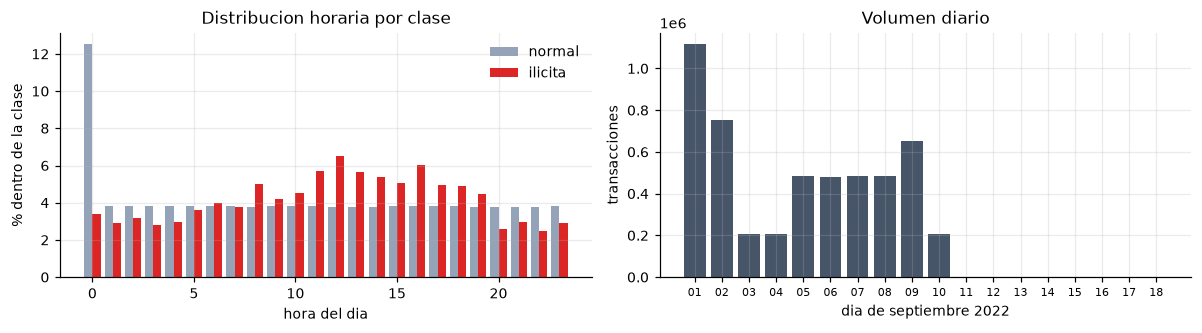

tx en la hora 0 (normales): 12.51 %   (ilicitas): 3.40 %
tx del 1 al 10 de septiembre: 99.98 % del total


In [7]:
hr = pd.crosstab(df["ts"].dt.hour, df["is_laundering"], normalize="columns") * 100
day = df["ts"].dt.date.value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.1))
ax[0].bar(hr.index - 0.2, hr[0], width=0.4, label="normal", color="#94a3b8")
ax[0].bar(hr.index + 0.2, hr[1], width=0.4, label="ilicita", color="#dc2626")
ax[0].set_xlabel("hora del dia"); ax[0].set_ylabel("% dentro de la clase")
ax[0].set_title("Distribucion horaria por clase"); ax[0].legend(frameon=False)

ax[1].bar(range(len(day)), day.values, color="#475569")
ax[1].set_xticks(range(len(day)))
ax[1].set_xticklabels([d.strftime("%d") for d in day.index], fontsize=7)
ax[1].set_xlabel("dia de septiembre 2022"); ax[1].set_ylabel("transacciones")
ax[1].set_title("Volumen diario")
plt.tight_layout(); plt.show()

print(f"tx en la hora 0 (normales): {hr.loc[0,0]:.2f} %   (ilicitas): {hr.loc[0,1]:.2f} %")
print(f"tx del 1 al 10 de septiembre: {100*day.iloc[:10].sum()/day.sum():.2f} % del total")

**Artefactos adicionales.** El **12.5 %** de las transacciones normales ocurre a la hora 0, frente al **3.8 %** en cualquier otra hora, debido al lote de inicialización del simulador concentrado el 1 de septiembre.

Además, el **99.98 %** del volumen ocurre en los primeros diez días, con una cola residual hasta el día 18. Esto descarta una partición temporal, ya que los patrones de lavado abarcan varios días y un corte cronológico podría dividirlos.


## 3. Evidencia para la longitud de secuencia

La distribución de longitudes determina dos decisiones: el **mínimo de transacciones por remitente** para entrar al dataset y la **longitud de ventana** a utilizar.


In [8]:
q = [.5, .75, .9, .95, .99, .999, 1.]
print("TRANSACCIONES POR REMITENTE")
print(f"  media {sender_tx.mean():.2f} | mediana {sender_tx.median():.0f} | "
      f"max {sender_tx.max():,}")
print("  percentiles:", {f"p{int(p*1000)/10}": int(sender_tx.quantile(p)) for p in q})

print()
print("EFECTO DEL MINIMO DE LONGITUD")
print(f"{'min_len':>7} | {'remitentes':>11} | {'positivos':>9} | {'% pos':>7} | {'% tx':>6}")
print("-" * 56)
for k in [1, 2, 3, 4, 5, 8, 10, 20]:
    keep = sender_tx[sender_tx >= k]
    npos = len(set(keep.index) & pos_senders)
    print(f"{k:>7} | {len(keep):>11,} | {npos:>9,} | "
          f"{100*npos/len(keep):>6.3f}% | {100*keep.sum()/n:>5.1f}%")

TRANSACCIONES POR REMITENTE
  media 10.22 | mediana 2 | max 168,672
  percentiles: {'p50.0': 2, 'p75.0': 5, 'p90.0': 29, 'p95.0': 46, 'p99.0': 92, 'p99.9': 159, 'p100.0': 168672}

EFECTO DEL MINIMO DE LONGITUD
min_len |  remitentes | positivos |   % pos |   % tx
--------------------------------------------------------
      1 |     496,995 |     3,376 |  0.679% | 100.0%
      2 |     344,245 |     3,254 |  0.945% |  97.0%
      3 |     185,993 |     2,758 |  1.483% |  90.8%
      4 |     142,306 |     2,085 |  1.465% |  88.2%
      5 |     128,779 |     1,626 |  1.263% |  87.1%
      8 |     115,279 |     1,255 |  1.089% |  85.6%
     10 |     110,008 |     1,185 |  1.077% |  84.7%
     20 |      76,833 |       887 |  1.154% |  75.6%


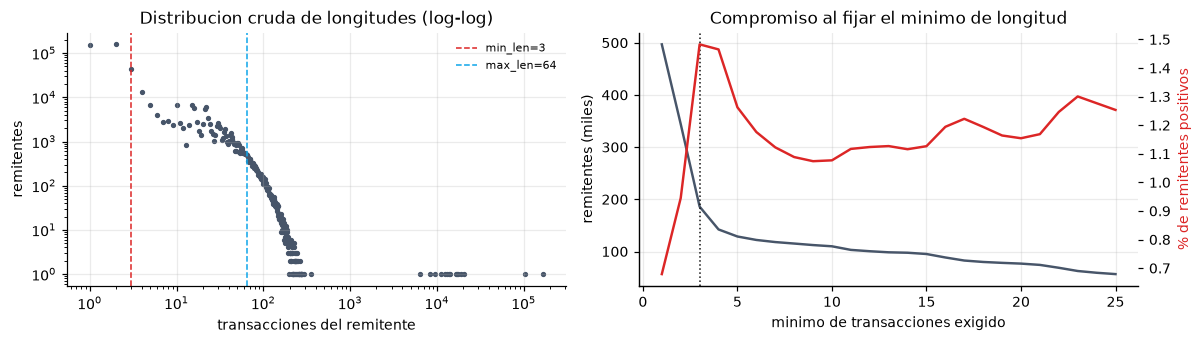

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
vc = sender_tx.value_counts().sort_index()
ax[0].scatter(vc.index, vc.values, s=6, color="#475569")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("transacciones del remitente"); ax[0].set_ylabel("remitentes")
ax[0].set_title("Distribucion cruda de longitudes (log-log)")
ax[0].axvline(CFG["MIN_LEN"], color="#dc2626", ls="--", lw=1, label=f"min_len={CFG['MIN_LEN']}")
ax[0].axvline(CFG["MAX_LEN"], color="#0ea5e9", ls="--", lw=1, label=f"max_len={CFG['MAX_LEN']}")
ax[0].legend(frameon=False, fontsize=7)

ks = np.arange(1, 26)
rem = [int((sender_tx >= k).sum()) for k in ks]
pct = [100 * len(set(sender_tx[sender_tx >= k].index) & pos_senders) / r
       for k, r in zip(ks, rem)]
a2 = ax[1]; a3 = a2.twinx()
a2.plot(ks, np.array(rem) / 1000, color="#475569", lw=1.6, label="remitentes (miles)")
a3.plot(ks, pct, color="#dc2626", lw=1.6, label="% positivos")
a2.axvline(CFG["MIN_LEN"], color="#111", ls=":", lw=1)
a2.set_xlabel("minimo de transacciones exigido"); a2.set_ylabel("remitentes (miles)")
a3.set_ylabel("% de remitentes positivos", color="#dc2626")
a3.grid(False)
a2.set_title("Compromiso al fijar el minimo de longitud")
plt.tight_layout(); plt.show()

In [10]:
inst = sender_tx[sender_tx > CFG["INST_TX_THR"]]
print(f"CUENTAS INSTITUCIONALES (> {CFG['INST_TX_THR']} tx)")
print(f" - cuentas            : {len(inst)}")
print(f" - transacciones      : {int(inst.sum()):,}  ({100*inst.sum()/n:.1f} % del total)")
print(f" - de ellas positivas : {len(set(inst.index) & pos_senders)}")
print()
print("  - top 8 por volumen:")
for a, c in inst.sort_values(ascending=False).head(8).items():
    print(f"   * {a:<12} {c:>9,} tx")
gap_lo = int(sender_tx[sender_tx <= CFG["INST_TX_THR"]].max())
gap_hi = int(inst.min()) if len(inst) else 0
print()
print(f"  hueco en la distribucion: nada entre {gap_lo:,} y {gap_hi:,} transacciones")
print("  Son dos poblaciones distintas, no una cola continua")
INST_ACCTS = set(inst.index)

CUENTAS INSTITUCIONALES (> 500 tx)
 - cuentas            : 15
 - transacciones      : 449,859  (8.9 % del total)
 - de ellas positivas : 15

  - top 8 por volumen:
   * 100428660      168,672 tx
   * 1004286A8      103,018 tx
   * 100428978       20,497 tx
   * 1004286F0       18,663 tx
   * 100428780       17,264 tx
   * 1004289C0       16,794 tx
   * 100428810       16,426 tx
   * 1004287C8       14,174 tx

  hueco en la distribucion: nada entre 351 y 6,431 transacciones
  Son dos poblaciones distintas, no una cola continua


**Decisión 2 | mínimo de 3 transacciones.** Descarta al **63 % de las cuentas**, pero conserva el **90.8 % del volumen** y eleva la proporción de remitentes positivos de **0.68 % a 1.48 %**. Un remitente con una o dos operaciones tampoco ofrece historial suficiente para un análisis de cumplimiento, por lo que el criterio es defendible operativa y estadísticamente.

**Decisión 3 | cuentas institucionales.** Quince cuentas superan las **500 transacciones** y concentran el **8.9 % del volumen**, con hasta **168 mil operaciones** cada una. No se eliminan porque son hubs relevantes, pero se marcan como cohorte separada para reportar el desempeño con y sin ellas. Su peso en el entrenamiento se controla mediante el tope de ventanas de la Decisión 5.


## 4. Ingeniería de features

Cada transacción se representa con **24 dimensiones** agrupadas en cuatro bloques. Cada *feature* corresponde a una señal de lavado relevante en remesas o a una variable necesaria para normalizar las demás.

| Bloque       | Features                                             | Señal que captura                                                 |
| ------------ | ---------------------------------------------------- | ----------------------------------------------------------------- |
| **Monto**    | `log_amt`, `amt_rel`                                 | Montos atípicos en absoluto y respecto al historial del remitente |
| **Tiempo**   | `log_dt`, `is_first_tx`, `hour_sin`, `hour_cos`      | Ráfagas de envíos y concentración horaria                         |
| **Destino**  | `dest_diversity`, `is_new_dest`, `is_self_transfer`  | Cambios de destinatario, dispersión y auto-transferencias         |
| **Contexto** | `is_cross_currency`, formato de pago (7), moneda (7) | Canal, corredor y saltos de divisa                                |

### Decisiones de codificación

`log_dt` mide el tiempo desde la transacción anterior **del mismo remitente**, no un timestamp absoluto: interesa el ritmo de las operaciones, no la fecha. `is_first_tx` permite distinguir la primera operación de un intervalo real de cero minutos.

`amt_rel` representa el monto en escala logarítmica respecto al promedio histórico del remitente hasta esa operación. Así, un mismo monto puede tener distinto significado según el comportamiento habitual de cada remitente.

La hora se codifica con **seno y coseno** para mantener adyacentes las 23:00 y las 00:00. Los montos pasan por `log1p` antes de estandarizar porque abarcan **dieciocho órdenes de magnitud**.


In [11]:
# Filtrado por longitud minima y orden temporal por remitente
keep = sender_tx[sender_tx >= CFG["MIN_LEN"]].index
work = df[df["from_acct"].isin(keep)].copy()
work["from_acct"] = work["from_acct"].cat.remove_unused_categories()
work = work.sort_values(["from_acct", "ts"], kind="mergesort").reset_index(drop=True)

print(f"remitentes: {work['from_acct'].nunique():,}")
print(f"transacciones: {len(work):,}  ({100*len(work)/n:.1f} % del total)")
del df; _ = gc.collect()

remitentes: 185,993
transacciones: 4,609,091  (90.8 % del total)


In [12]:
t = time.time()
gcol = work.groupby("from_acct", observed=True)
pos_in_seq = gcol.cumcount().to_numpy() + 1 # posicion 1-based dentro del remitente

# Bloque 1: monto
work["log_amt"] = np.log1p(work["amt_paid"].to_numpy())
la = work["log_amt"].to_numpy()
csum = work.groupby("from_acct", observed=True)["log_amt"].cumsum().to_numpy()
prev_mean = (csum - la) / np.maximum(pos_in_seq - 1, 1)
work["amt_rel"] = np.where(pos_in_seq > 1, la - prev_mean, 0.0).astype("float32") # desviacion respecto al promedio historico del propio remitente

# Bloque 2: tiempo
dt_min = gcol["ts"].diff().dt.total_seconds().to_numpy() / 60.0
work["is_first_tx"] = np.isnan(dt_min).astype("float32")
work["log_dt"] = np.log1p(np.clip(np.nan_to_num(dt_min, nan=0.0), 0, None))

hour = work["ts"].dt.hour.to_numpy() + work["ts"].dt.minute.to_numpy() / 60.0
work["hour_sin"] = np.sin(2 * np.pi * hour / 24)
work["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Bloque 3: destino
work["is_new_dest"] = (~work.duplicated(subset=["from_acct", "to_acct"], keep="first")).astype("float32") # primera aparicion de cada par (remitente, destino) = destino nuevo para ese remitente
uniq_so_far = work.groupby("from_acct", observed=True)["is_new_dest"].cumsum().to_numpy()
work["dest_diversity"] = (uniq_so_far / pos_in_seq).astype("float32")
work["is_self_transfer"] = (work["from_acct"].astype(str) == work["to_acct"].astype(str)).astype("float32")

# Bloque 4: contexto
work["is_cross_currency"] = (work["cur_recv"].astype(str) != work["cur_paid"].astype(str)).astype("float32")
print(f"features derivadas en {time.time()-t:.1f} s")
print(work[["log_amt", "amt_rel", "log_dt", "is_first_tx", "dest_diversity",
            "is_new_dest", "is_self_transfer", "is_cross_currency"]]
      .describe().round(3).to_string())

features derivadas en 6.2 s
           log_amt      amt_rel       log_dt  is_first_tx  dest_diversity  is_new_dest  is_self_transfer  is_cross_currency
count  4609091.000  4609091.000  4609091.000  4609091.000     4609091.000  4609091.000       4609091.000        4609091.000
mean         7.458       -0.082        3.426        0.040           0.311        0.146             0.067              0.016
std          3.351        2.447        2.628        0.197           0.257        0.353             0.250              0.124
min          0.000      -18.940        0.000        0.000           0.019        0.000             0.000              0.000
25%          5.283       -1.367        1.386        0.000           0.122        0.000             0.000              0.000
50%          7.300       -0.065        2.639        0.000           0.213        0.000             0.000              0.000
75%          9.430        1.045        6.064        0.000           0.429        0.000             0.000

In [13]:
# Bloque 4: categoricas
FMT_LEVELS = ["ACH", "Bitcoin", "Cash", "Cheque", "Credit Card", "Reinvestment", "Wire"]
CUR_TOP = ["US Dollar", "Euro", "Swiss Franc", "Yuan", "Shekel", "Rupee"]

fmt_oh = pd.get_dummies(work["fmt"].astype(str)).reindex(columns=FMT_LEVELS, fill_value=0)
fmt_oh.columns = [f"fmt_{c.replace(' ', '_')}" for c in fmt_oh.columns]

cur = work["cur_paid"].astype(str).where(work["cur_paid"].astype(str).isin(CUR_TOP), "Other")
cur_oh = pd.get_dummies(cur).reindex(columns=CUR_TOP + ["Other"], fill_value=0)
cur_oh.columns = [f"cur_{c.replace(' ', '_')}" for c in cur_oh.columns]

NUM_FEATS = ["log_amt", "amt_rel", "log_dt", "is_first_tx", "hour_sin", "hour_cos",
             "dest_diversity", "is_new_dest", "is_self_transfer", "is_cross_currency"]
FEATURES = NUM_FEATS + list(fmt_oh.columns) + list(cur_oh.columns)
STANDARDIZE = ["log_amt", "amt_rel", "log_dt"]   # el resto ya vive en [-1, 1]

X = np.concatenate([
    work[NUM_FEATS].to_numpy(dtype="float32"),
    fmt_oh.to_numpy(dtype="float32"),
    cur_oh.to_numpy(dtype="float32"),
], axis=1)

print(f"matriz de features: {X.shape}  ({X.nbytes/1e6:.0f} MB, float32)")
print(f"dimensiones ({len(FEATURES)}):")
for i in range(0, len(FEATURES), 5):
    print("   ", ", ".join(FEATURES[i:i+5]))
del fmt_oh, cur_oh, cur; _ = gc.collect()

matriz de features: (4609091, 24)  (442 MB, float32)
dimensiones (24):
    log_amt, amt_rel, log_dt, is_first_tx, hour_sin
    hour_cos, dest_diversity, is_new_dest, is_self_transfer, is_cross_currency
    fmt_ACH, fmt_Bitcoin, fmt_Cash, fmt_Cheque, fmt_Credit_Card
    fmt_Reinvestment, fmt_Wire, cur_US_Dollar, cur_Euro, cur_Swiss_Franc
    cur_Yuan, cur_Shekel, cur_Rupee, cur_Other


## 5. Construcción de secuencias

Las transacciones ordenadas de cada remitente se dividen en **ventanas contiguas no solapadas** de `MAX_LEN`. Se prefiere ventanear a truncar, ya que conservar solo las últimas N operaciones podría excluir transacciones ilícitas y convertir un caso positivo en un negativo mal etiquetado.

### Reglas aplicadas

1. Una ventana es **positiva** si contiene al menos una transacción marcada.
2. Las ventanas **sin transacciones marcadas** de un remitente positivo se descartan por ambiguas, evitando introducir ruido de supervisión.
3. Las ventanas con menos de `MIN_LEN` transacciones se descartan.
4. Se limita a `CAP_WINDOWS` ventanas por remitente, **muestreadas al azar** a lo largo de su historial. Así se evita que las cuentas institucionales queden representadas únicamente por la actividad inicial del simulador.


In [14]:
sender_codes = work["from_acct"].cat.codes.to_numpy().astype(np.int64)
ill = work["is_laundering"].to_numpy().astype(np.int64)
pos_in_sender = work.groupby("from_acct", observed=True).cumcount().to_numpy().astype(np.int64)
CATS = np.asarray(work["from_acct"].cat.categories, dtype=object)
BIG = 20000

def build_windows(max_len, cap, min_len=CFG["MIN_LEN"], seed=SEED):
    win = pos_in_sender // max_len
    key = sender_codes * BIG + win
    uk, inv = np.unique(key, return_inverse=True)
    w_len = np.bincount(inv, minlength=len(uk))
    w_ill = np.bincount(inv, weights=ill, minlength=len(uk)).astype(np.int64)
    w_sender, w_idx = uk // BIG, uk % BIG
    is_pos_sender = np.isin(w_sender, np.unique(sender_codes[ill > 0]))

    ok = (w_len >= min_len) & ~(is_pos_sender & (w_ill == 0))
    # tope por remitente: muestreo aleatorio, priorizando ventanas con evidencia
    r = np.random.default_rng(seed)
    prio = np.where(w_ill > 0, -1.0, r.random(len(uk)))   # las positivas nunca se sacrifican
    order = np.lexsort((prio, w_sender))
    ranks = np.empty(len(uk), np.int64)
    ranks[order] = np.arange(len(uk))
    first = np.r_[0, np.cumsum(np.bincount(w_sender[order], minlength=w_sender.max() + 1))[:-1]]
    within = ranks - first[w_sender]
    ok &= within < cap
    return uk, inv, w_len, w_ill, w_sender, w_idx, ok

uk, inv, w_len, w_ill, w_sender, w_idx, ok = build_windows(CFG["MAX_LEN"], CFG["CAP_WINDOWS"])
print(f"ventanas brutas    : {len(uk):,}")
print(f"ventanas retenidas : {int(ok.sum()):,}")
print(f"positivas        : {int((ok & (w_ill > 0)).sum()):,}"
      f"  ({100*(ok & (w_ill>0)).sum()/ok.sum():.3f} %)")

ventanas brutas    : 207,432
ventanas retenidas : 199,364
positivas        : 3,003  (1.506 %)


In [15]:
# Barrido que respalda la eleccion de MAX_LEN y CAP_WINDOWS
rows = []
for ml in [32, 64, 128]:
    for cp in [5, 10, 20, 10**6]:
        _, _, l_, i_, s_, _, o_ = build_windows(ml, cp)
        npos = int((o_ & (i_ > 0)).sum()); ntot = int(o_.sum())
        top = np.bincount(s_[o_], minlength=s_.max() + 1)
        rows.append({"max_len": ml, "cap": "inf" if cp > 1e5 else cp,
                     "secuencias": ntot, "positivas": npos,
                     "% pos": round(100 * npos / ntot, 3),
                     "max win/remit": int(top.max()),
                     "len media": round(float(l_[o_].mean()), 1)})
print("BARRIDO DE CONFIGURACIONES DE VENTANA")
print(pd.DataFrame(rows).to_string(index=False))

BARRIDO DE CONFIGURACIONES DE VENTANA
 max_len cap  secuencias  positivas  % pos  max win/remit  len media
      32   5      242085       2859  1.181              5       17.0
      32  10      242770       2932  1.208             10       17.0
      32  20      242873       3034  1.249             20       17.0
      32 inf      243239       3400  1.398            238       17.1
      64   5      199193       2833  1.422              5       20.8
      64  10      199267       2906  1.458             10       20.9
      64  20      199364       3003  1.506             20       20.9
      64 inf      199725       3364  1.684            236       21.0
     128   5      187367       2823  1.507              5       22.2
     128  10      187439       2895  1.545             10       22.3
     128  20      187532       2988  1.593             20       22.3
     128 inf      187877       3333  1.774            230       22.5


**Decisión 4 | ventana de 64.** Con 128, el costo de la capa de atención se cuadruplica para ganar apenas una décima de punto en tasa de positivos. Con 32, la tasa disminuye al generarse más ventanas negativas por remitente. **64 cubre por completo a más del 95 % de los remitentes** y se ajusta al presupuesto de 30 minutos en T4.

**Decisión 5 | tope de 20 ventanas por remitente.** Sin tope, la cuenta de mayor volumen genera más de **2,600 secuencias**. Con el límite, las quince cuentas institucionales representan una fracción marginal del dataset. El muestreo prioriza ventanas con evidencia, evitando que un remitente positivo pierda su caso por efecto del tope.


## 6. Separación train / val / test
Los patrones de lavado son **redes**: la cuenta receptora de un salto puede ser la emisora del siguiente. Separar por transacción produciría fuga, pero hacerlo solo por remitente tampoco basta, ya que los **370 patrones documentados** comparten cuentas.

### Procedimiento
1. Parsear `HI-Small_Patterns.txt` y extraer las cuentas de cada patrón.
2. Unir mediante *union-find* los patrones que comparten al menos una cuenta, formando **componentes conexos indivisibles**.
3. Usar como unidad de partición el componente completo para cuentas involucradas en patrones y el remitente individual para el resto.
4. Asignar las unidades mediante un algoritmo voraz balanceado por **número de secuencias positivas**, evitando que los componentes grandes concentren los casos en un solo *split*.


In [16]:
groups, cur = [], None
with open(HI_PATT, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.rstrip("\n"); up = line.upper()
        if up.startswith("BEGIN LAUNDERING ATTEMPT"):
            label = line.split("-", 1)[1].strip() if "-" in line else "?"
            cur = {"tipo": label.split(":", 1)[0].strip(), "detalle": label, "accts": set()}
        elif up.startswith("END LAUNDERING ATTEMPT"):
            if cur: groups.append(cur); cur = None
        elif line.strip() and cur is not None:
            p = line.split(",")
            if len(p) >= 5:
                cur["accts"].update([p[2], p[4]])

print(f"patrones documentados: {len(groups)}")
tip = Counter(g["tipo"] for g in groups)
print("tipologias:", ", ".join(f"{k} ({v})" for k, v in tip.most_common()))

acct2grp = defaultdict(set)
for i, g in enumerate(groups):
    for a in g["accts"]:
        acct2grp[a].add(i)

parent = list(range(len(groups)))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for gs in acct2grp.values():
    gs = sorted(gs)
    for j in gs[1:]:
        a, b = find(gs[0]), find(j)
        if a != b: parent[b] = a

comp_of_acct = {a: find(next(iter(gs))) for a, gs in acct2grp.items()}
ncomp = len(set(comp_of_acct.values()))
print(f"cuentas en patrones: {len(acct2grp):,}")
print(f"componentes conexos: {ncomp}  (unidades indivisibles para el split)")

patrones documentados: 370
tipologias: CYCLE (54), GATHER-SCATTER (51), BIPARTITE (49), FAN-OUT (48), SCATTER-GATHER (44), STACK (43), RANDOM (41), FAN-IN (40)
cuentas en patrones: 3,170
componentes conexos: 210  (unidades indivisibles para el split)


In [17]:
# Unidad de particion por remitente
sender_names = CATS # nombre por codigo de remitente
unit_of_sender = np.empty(len(sender_names), dtype=object)
for c, name in enumerate(sender_names):
    comp = comp_of_acct.get(str(name))
    unit_of_sender[c] = f"C{comp}" if comp is not None else f"S{c}"

sel = np.where(ok)[0] # ventanas retenidas
w_unit = unit_of_sender[w_sender[sel]]
w_label = (w_ill[sel] > 0).astype(np.int8)

udf = pd.DataFrame({"unit": w_unit, "y": w_label})
agg = udf.groupby("unit").agg(n=("y", "size"), pos=("y", "sum")).sort_values(["pos", "n"], ascending=False)

print(f"unidades de particion : {len(agg):,}")
print(f" - con al menos un positivo: {int((agg['pos']>0).sum()):,}")
print(f" - unidad mas grande       : {int(agg['n'].max()):,} secuencias, "
      f"{int(agg['pos'].max())} positivas")

unidades de particion : 183,716
 - con al menos un positivo: 1,072
 - unidad mas grande       : 365 secuencias, 196 positivas


In [18]:
# Cada unidad va al split con mayor deficit relativo de positivos
tr, va, te = CFG["SPLITS"]
targets = np.array([tr, va, te])
tot_pos, tot_n = int(agg["pos"].sum()), int(agg["n"].sum())
cur_pos, cur_n = np.zeros(3), np.zeros(3)
assign = {}

for unit, row in agg.iterrows():
    if row["pos"] > 0:
        deficit = targets * tot_pos - cur_pos
    else:
        deficit = targets * tot_n - cur_n
    k = int(np.argmax(deficit))
    assign[unit] = k
    cur_pos[k] += row["pos"]; cur_n[k] += row["n"]

split_of_window = np.array([assign[u] for u in w_unit], dtype=np.int8)

names = ["train", "val", "test"]
print(f"{'split':>6} | {'secuencias':>11} | {'positivas':>9} | {'% pos':>7} | {'% del total':>11}")
print("-" * 60)
for k in range(3):
    m = split_of_window == k
    npos = int(w_label[m].sum())
    print(f"{names[k]:>6} | {int(m.sum()):>11,} | {npos:>9,} | "
          f"{100*npos/max(m.sum(),1):>6.3f}% | {100*m.mean():>10.1f}%")

 split |  secuencias | positivas |   % pos | % del total
------------------------------------------------------------
 train |     139,555 |     2,102 |  1.506% |       70.0%
   val |      29,905 |       451 |  1.508% |       15.0%
  test |      29,904 |       450 |  1.505% |       15.0%


In [19]:
# Verificacion de ausencia de fuga
by_unit = pd.DataFrame({"unit": w_unit, "split": split_of_window})
bad_units = by_unit.groupby("unit")["split"].nunique()
by_send = pd.DataFrame({"s": w_sender[sel], "split": split_of_window})
bad_send = by_send.groupby("s")["split"].nunique()

print("unidades presentes en mas de un split :", int((bad_units > 1).sum()))
print("remitentes presentes en mas de un split:", int((bad_send > 1).sum()))
assert (bad_units <= 1).all() and (bad_send <= 1).all(), "FUGA DETECTADA"
print("\nSin fuga: cada remitente y cada componente de patron vive en un unico split.")

unidades presentes en mas de un split : 0
remitentes presentes en mas de un split: 0

Sin fuga: cada remitente y cada componente de patron vive en un unico split.


## 7. Normalización

Solo `log_amt`, `amt_rel` y `log_dt` requieren estandarización; el resto de las *features* ya se encuentra en `[-1, 1]` por construcción. Los estadísticos se calculan **exclusivamente con el conjunto de entrenamiento** y se aplican a los tres *splits*, evitando fuga de información desde validación o test.

Tras estandarizar, los valores se recortan a **±5 desviaciones estándar**. Sin este límite, los montos extremos (hasta **1.05e12**) podrían dominar el error de reconstrucción de la Etapa A y hacer que el score detecte magnitud en lugar de patrones de comportamiento. La fracción de valores afectada por el recorte se reporta a continuación.


In [20]:
w_start = np.r_[0, np.cumsum(w_len)[:-1]].astype(np.int64)
w_end = (w_start + w_len).astype(np.int64)
s_start, s_end = w_start[sel], w_end[sel]

train_rows = np.zeros(len(X), dtype=bool)
for a, b in zip(s_start[split_of_window == 0], s_end[split_of_window == 0]):
    train_rows[a:b] = True

idx_std = [FEATURES.index(c) for c in STANDARDIZE]
mu = X[train_rows][:, idx_std].mean(axis=0)
sd = X[train_rows][:, idx_std].std(axis=0) + 1e-8
X[:, idx_std] = (X[:, idx_std] - mu) / sd

print("estadisticos ajustados solo en train:")
for c, m, s in zip(STANDARDIZE, mu, sd):
    print(f"  {c:<10} media={m:8.4f}  desv={s:8.4f}")
print(f"\ntransacciones de entrenamiento usadas: {int(train_rows.sum()):,}")
print(f"rango antes del recorte: [{X.min():.2f}, {X.max():.2f}]")

CLIP = CFG["CLIP_SIGMA"]
sub = X[:, idx_std]
n_clip = int((np.abs(sub) > CLIP).sum())
print(f"\nrecorte a +-{CLIP:.0f} desviaciones:")
for j, c in zip(idx_std, STANDARDIZE):
    k = int((np.abs(X[:, j]) > CLIP).sum())
    print(f"  {c:<10} {k:>8,} valores  ({100*k/len(X):.4f} % de las transacciones)")
X[:, idx_std] = np.clip(sub, -CLIP, CLIP)
print(f"\ntotal recortado: {n_clip:,} de {sub.size:,} valores ({100*n_clip/sub.size:.4f} %)")
print(f"rango final de X: [{X.min():.2f}, {X.max():.2f}]")

estadisticos ajustados solo en train:
  log_amt    media=  7.3928  desv=  3.3873
  amt_rel    media= -0.0739  desv=  2.4073
  log_dt     media=  3.6693  desv=  2.4857

transacciones de entrenamiento usadas: 3,180,692
rango antes del recorte: [-7.84, 8.79]

recorte a +-5 desviaciones:
  log_amt          40 valores  (0.0009 % de las transacciones)
  amt_rel       3,817 valores  (0.0828 % de las transacciones)
  log_dt            0 valores  (0.0000 % de las transacciones)

total recortado: 3,857 de 13,827,273 valores (0.0279 %)
rango final de X: [-5.00, 5.00]


### Balanceo para cada etapa

El desbalance se aborda de forma distinta en cada etapa, ya que resuelven problemas diferentes.

**Etapa A.** Se entrena solo con remitentes sin transacciones marcadas **y** que no aparecen en ningún patrón documentado. Así se evita contaminar la definición de normalidad con cuentas pertenecientes a redes de lavado.

**Etapa B.** Conserva todos los positivos y submuestrea negativos a **1:10**. No se balancea a 1:1 para preservar mejor la calibración de probabilidades y el umbral de decisión. El desbalance residual se compensa en la función de pérdida del Componente 2.


In [21]:
patt_accounts = set(acct2grp.keys())
sender_is_patt = np.array([str(nm) in patt_accounts for nm in sender_names])
clean_sender = ~sender_is_patt[w_sender[sel]]

stage_a = (split_of_window == 0) & (w_label == 0) & clean_sender
print(f"ETAPA A (solo normalidad)")
print(f"  secuencias de entrenamiento : {int(stage_a.sum()):,}")
print(f"  excluidas por pertenecer a un patron: "
      f"{int(((split_of_window==0) & (w_label==0) & ~clean_sender).sum()):,}")
r = np.random.default_rng(SEED)
tr_pos = np.where((split_of_window == 0) & (w_label == 1))[0]
tr_neg = np.where((split_of_window == 0) & (w_label == 0))[0]
n_neg = min(len(tr_neg), CFG["NEG_POS_RATIO"] * len(tr_pos))
stage_b_idx = np.sort(np.concatenate([tr_pos, r.choice(tr_neg, n_neg, replace=False)]))


print(f"\nETAPA B (supervisada, submuestreo 1:{CFG['NEG_POS_RATIO']})")
print(f"  positivas : {len(tr_pos):,}")
print(f"  negativas : {n_neg:,}")
print(f"  total     : {len(stage_b_idx):,}")
print(f"\nVal y test conservan la proporcion natural para que las metricas sean realistas.")

ETAPA A (solo normalidad)
  secuencias de entrenamiento : 136,875
  excluidas por pertenecer a un patron: 578

ETAPA B (supervisada, submuestreo 1:10)
  positivas : 2,102
  negativas : 21,020
  total     : 23,122

Val y test conservan la proporcion natural para que las metricas sean realistas.


## 8. Verificación obligatoria

Se realizan las **tres comprobaciones exigidas** antes de iniciar cualquier modelado.


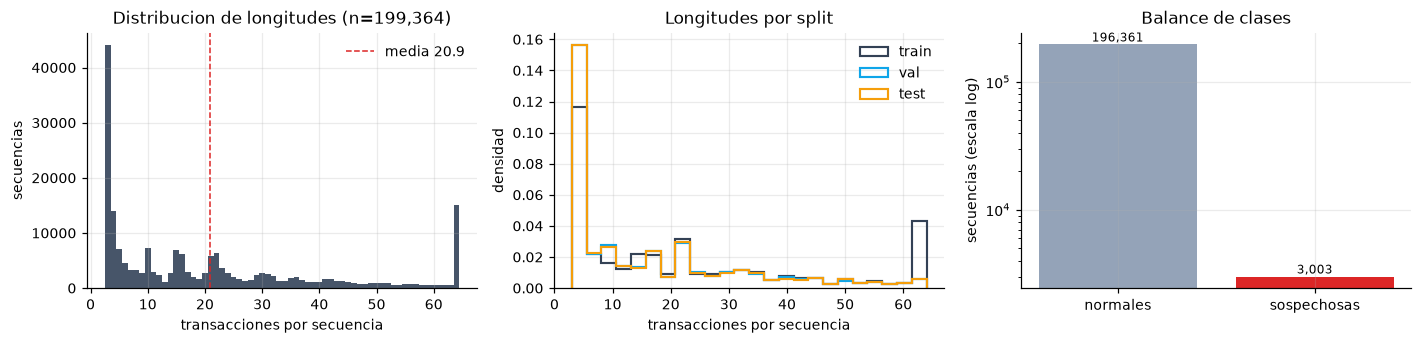

longitudes: min 3  mediana 15  media 20.9  max 64
positivas: 3,003 de 199,364  (1.506 %)
ratio: 1 sospechosa por cada 65 normales


In [22]:
lens = w_len[sel]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))

ax[0].hist(lens, bins=np.arange(CFG["MIN_LEN"], CFG["MAX_LEN"] + 2) - .5,
           color="#475569", edgecolor="none")
ax[0].set_xlabel("transacciones por secuencia"); ax[0].set_ylabel("secuencias")
ax[0].set_title(f"Distribucion de longitudes (n={len(lens):,})")
ax[0].axvline(lens.mean(), color="#dc2626", ls="--", lw=1,
              label=f"media {lens.mean():.1f}")
ax[0].legend(frameon=False)

for k, cl in zip(range(3), ["#334155", "#0ea5e9", "#f59e0b"]):
    m = split_of_window == k
    ax[1].hist(lens[m], bins=24, histtype="step", lw=1.4, color=cl,
               density=True, label=names[k])
ax[1].set_xlabel("transacciones por secuencia"); ax[1].set_ylabel("densidad")
ax[1].set_title("Longitudes por split"); ax[1].legend(frameon=False)

cnt = [int((w_label == 0).sum()), int((w_label == 1).sum())]
b = ax[2].bar(["normales", "sospechosas"], cnt, color=["#94a3b8", "#dc2626"])
ax[2].set_yscale("log"); ax[2].set_ylabel("secuencias (escala log)")
ax[2].set_title("Balance de clases")
for rect, v in zip(b, cnt):
    ax[2].text(rect.get_x() + rect.get_width()/2, v, f"{v:,}",
               ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

print(f"longitudes: min {lens.min()}  mediana {int(np.median(lens))}  "
      f"media {lens.mean():.1f}  max {lens.max()}")
print(f"positivas: {cnt[1]:,} de {sum(cnt):,}  ({100*cnt[1]/sum(cnt):.3f} %)")
print(f"ratio: 1 sospechosa por cada {cnt[0]/cnt[1]:.0f} normales")

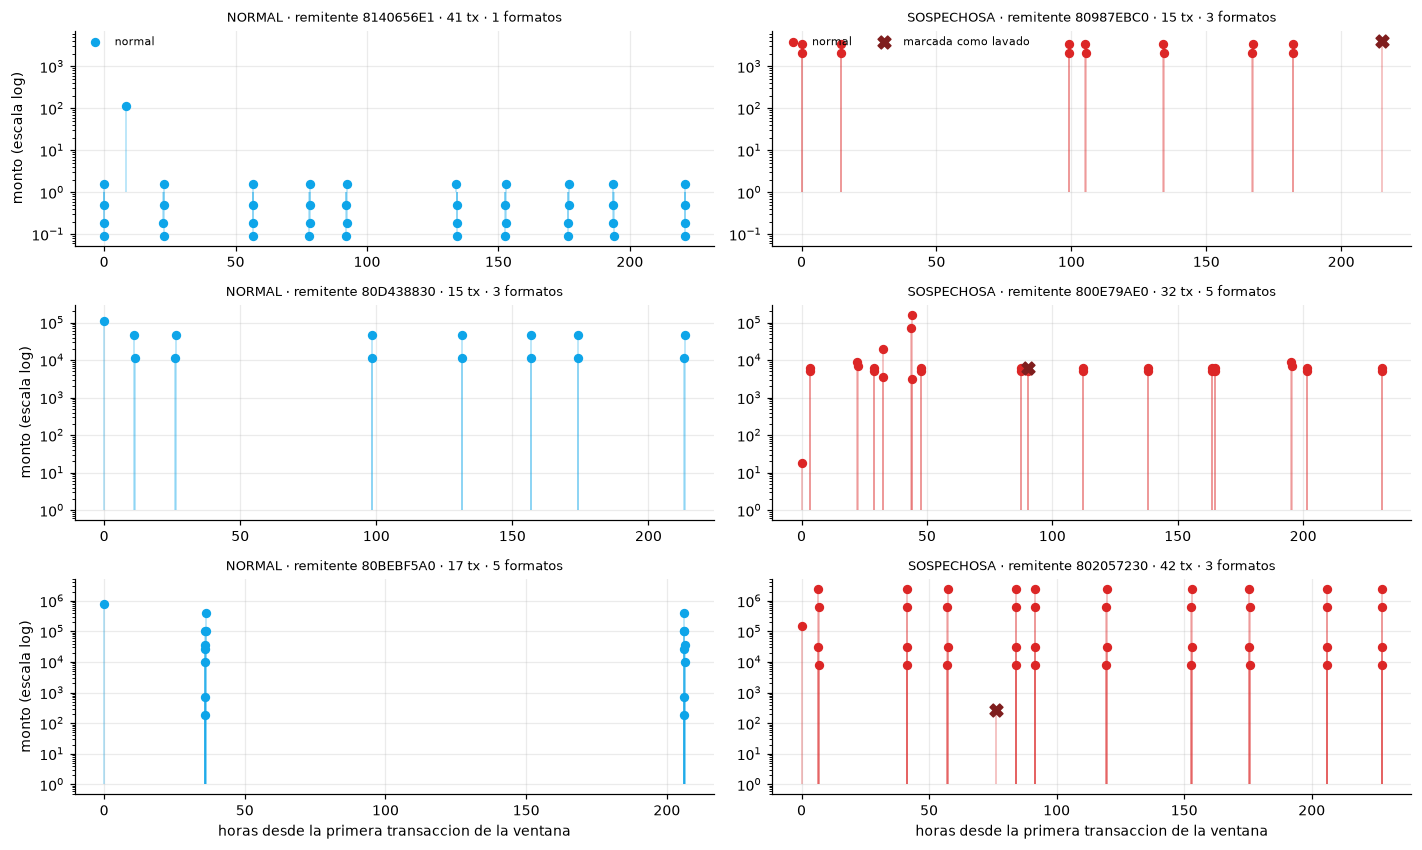

In [23]:
# Tres pares de ejemplos: secuencias normales frente a sospechosas
meta_ts = work["ts"].to_numpy()
meta_amt = work["amt_paid"].to_numpy()
meta_ill = work["is_laundering"].to_numpy()
meta_fmt = work["fmt"].cat.codes.to_numpy()
meta_newdest = work["is_new_dest"].to_numpy()

cand_pos = [i for i in np.where(w_label == 1)[0] if 12 <= lens[i] <= 45]
cand_neg = [i for i in np.where(w_label == 0)[0] if 12 <= lens[i] <= 45]
rr = np.random.default_rng(7)
pick_pos = rr.choice(cand_pos, 3, replace=False)
pick_neg = rr.choice(cand_neg, 3, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(13, 7.8))
for row in range(3):
    axes[row, 0].sharey(axes[row, 1])      # misma escala dentro de cada par
    for col, (idx, titulo, base) in enumerate([
            (pick_neg[row], "NORMAL", "#0ea5e9"),
            (pick_pos[row], "SOSPECHOSA", "#dc2626")]):
        a, b = s_start[idx], s_end[idx]
        t = (meta_ts[a:b] - meta_ts[a]) / np.timedelta64(1, "h")
        y = meta_amt[a:b]; z = meta_ill[a:b].astype(bool)
        ax = axes[row, col]
        ax.vlines(t, 1, y, color=base, alpha=.35, lw=1)
        ax.scatter(t[~z], y[~z], s=26, color=base, zorder=3, label="normal")
        if z.any():
            ax.scatter(t[z], y[z], s=70, color="#7f1d1d", marker="X",
                       zorder=4, label="marcada como lavado")
        ax.set_yscale("log")
        ax.set_title(f"{titulo} · remitente {sender_names[w_sender[sel][idx]]} · "
                     f"{b-a} tx · {len(set(meta_fmt[a:b]))} formatos", fontsize=8.5)
        if row == 2: ax.set_xlabel("horas desde la primera transaccion de la ventana")
        if col == 0: ax.set_ylabel("monto (escala log)")
        if row == 0: ax.legend(frameon=False, fontsize=7, loc="upper left",
                               ncol=2, bbox_to_anchor=(0, 1.02))
plt.tight_layout(); plt.show()

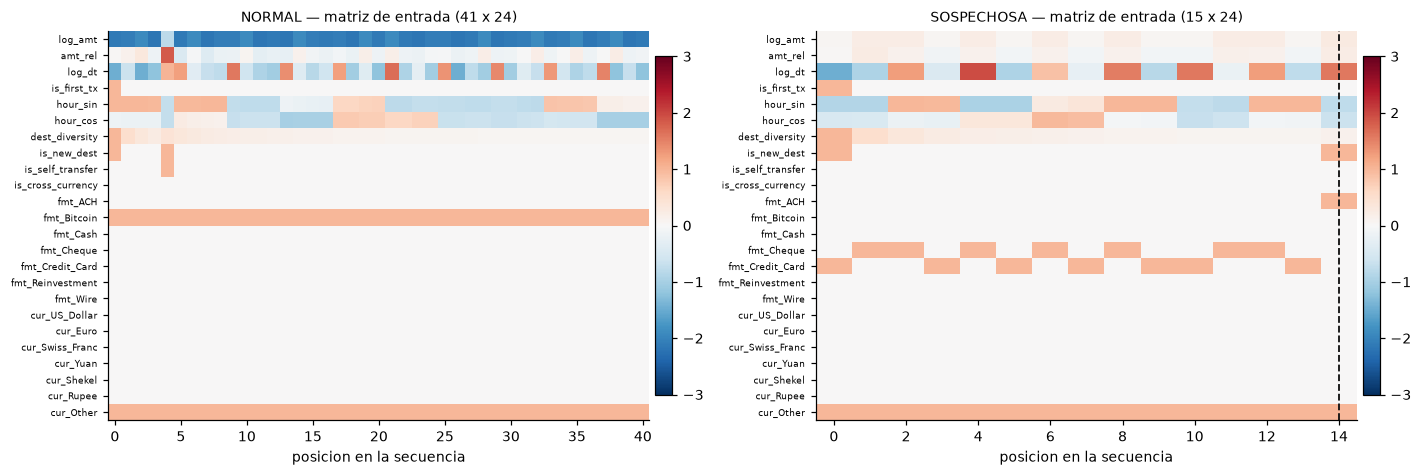

Las lineas punteadas marcan las transacciones etiquetadas como lavado.
Una secuencia sospechosa contiene en promedio 1.39 transacciones marcadas
sobre una longitud media de 20.5: el modelo debe localizar una o
dos posiciones anomalas entre decenas, lo que justifica el pooling top-k del score.


In [24]:
# Lo que realmente ve el modelo: la matriz de features de un par de ejemplos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, idx, titulo in [(axes[0], pick_neg[0], "NORMAL"),
                        (axes[1], pick_pos[0], "SOSPECHOSA")]:
    a, b = s_start[idx], s_end[idx]
    m = X[a:b].T
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3,
                   interpolation="nearest")
    ax.set_yticks(range(len(FEATURES)))
    ax.set_yticklabels(FEATURES, fontsize=6)
    ax.set_xlabel("posicion en la secuencia")
    ax.set_title(f"{titulo} — matriz de entrada ({b-a} x {len(FEATURES)})", fontsize=9)
    ax.grid(False)
    for j in np.where(meta_ill[a:b] == 1)[0]:
        ax.axvline(j, color="#111", lw=1.2, ls="--")
    fig.colorbar(im, ax=ax, fraction=.03, pad=.01)
plt.tight_layout(); plt.show()
ill_por_seq = w_ill[sel][w_label == 1].mean()
print(f"Las lineas punteadas marcan las transacciones etiquetadas como lavado.")
print(f"Una secuencia sospechosa contiene en promedio {ill_por_seq:.2f} transacciones marcadas")
print(f"sobre una longitud media de {lens[w_label==1].mean():.1f}: el modelo debe localizar una o")
print("dos posiciones anomalas entre decenas, lo que justifica el pooling top-k del score.")

In [25]:
# Comparacion agregada normal vs sospechosa, mas alla de los ejemplos individuales
pos_w = np.where(w_label == 1)[0]
neg_w = np.where(w_label == 0)[0]
rows = []
for nm, ws in [("normales", rr.choice(neg_w, 5000, replace=False)), ("sospechosas", pos_w)]:
    dur, nd, amp, gap = [], [], [], []
    for i in ws:
        a, b = s_start[i], s_end[i]
        h = (meta_ts[a:b] - meta_ts[a]) / np.timedelta64(1, "h")
        dur.append(h[-1]); nd.append(meta_newdest[a:b].mean())
        amp.append(np.log10(meta_amt[a:b].max() / max(meta_amt[a:b].min(), 1e-6)))
        gap.append(np.median(np.diff(h)) if b - a > 1 else 0)
    rows.append({"grupo": nm, "n": len(ws),
                 "duracion (h)": round(float(np.median(dur)), 1),
                 "% destinos nuevos": round(100 * float(np.median(nd)), 1),
                 "amplitud montos (ordenes)": round(float(np.median(amp)), 2),
                 "gap mediano (h)": round(float(np.median(gap)), 2)})
print("PERFIL AGREGADO (medianas)")
print(pd.DataFrame(rows).to_string(index=False))

PERFIL AGREGADO (medianas)
      grupo    n  duracion (h)  % destinos nuevos  amplitud montos (ordenes)  gap mediano (h)
   normales 5000         201.0               17.6                       3.05             1.97
sospechosas 3003         189.3               50.0                       3.45             3.85


## 9. Exportación

Se guarda una representación **compacta**: una única matriz de *features* para todas las transacciones, junto con los índices de inicio y fin de cada ventana.

Esto evita materializar el tensor con relleno y permite que el `DataLoader` del Componente 2 construya lotes con **relleno dinámico**, más eficiente en GPU.


In [26]:
np.savez(
    OUT_DIR / "sequences.npz",
    X=X,
    win_start=s_start.astype(np.int64), win_end=s_end.astype(np.int64),
    y=w_label.astype(np.int8), split=split_of_window.astype(np.int8),
    sender_code=w_sender[sel].astype(np.int32),
    is_illicit_tx=meta_ill.astype(np.int8),
    stage_a_mask=stage_a, stage_b_idx=stage_b_idx.astype(np.int64),
    is_institutional=np.array([str(nm) in INST_ACCTS for nm in sender_names]),
)
with open(OUT_DIR / "meta.json", "w") as f:
    json.dump({"features": FEATURES, "standardize": STANDARDIZE,
               "mu": mu.tolist(), "sd": sd.tolist(), "cfg": CFG,
               "sender_names": [str(x) for x in sender_names],
               "n_sequences": int(len(s_start)),
               "n_positive": int(w_label.sum())}, f)

# Metadatos legibles de test, para el analisis de casos y el MVP
te_idx = np.where(split_of_window == 2)[0]
rows_te = np.concatenate([np.arange(s_start[i], s_end[i]) for i in te_idx])
test_tx = work.iloc[rows_te][["from_acct", "to_acct", "ts", "amt_paid",
                              "cur_paid", "fmt", "is_laundering"]]
try:
    test_tx.to_parquet(OUT_DIR / "test_tx.parquet", index=True)
except ImportError:
    test_tx.to_csv(OUT_DIR / "test_tx.csv.gz", index=True, compression="gzip")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<24} {p.stat().st_size/1e6:>8,.1f} MB")
print(f"\ntiempo total del notebook: {(time.time()-T0)/60:.1f} min")

  meta.json                     2.4 MB
  sequences.npz               452.0 MB
  test_tx.parquet              10.1 MB

tiempo total del notebook: 1.2 min


In [27]:
# Verificacion de que los artefactos se leen correctamente
z = np.load(OUT_DIR / "sequences.npz")
meta = json.load(open(OUT_DIR / "meta.json"))
i = int(np.where(z["y"] == 1)[0][0])
seq = z["X"][z["win_start"][i]:z["win_end"][i]]
print("secuencias:", len(z["y"]), "| features:", len(meta["features"]))
print("ejemplo positivo -> shape", seq.shape, "| etiqueta", int(z["y"][i]),
      "| split", int(z["split"][i]))
print("reparto:", {names[k]: int((z["split"] == k).sum()) for k in range(3)})

secuencias: 199364 | features: 24
ejemplo positivo -> shape (64, 24) | etiqueta 1 | split 0
reparto: {'train': 139555, 'val': 29905, 'test': 29904}


## Resumen de decisiones

|    #   | Decisión                                           | Justificación                                                                                                                       |
| :----: | -------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
|  **1** | IBM AML HI-Small; PaySim excluido                  | PaySim tiene 1.00 tx por remitente: no admite secuencias y su etiqueta es fraude, no lavado                                         |
|  **2** | Mínimo de 3 transacciones                          | Conserva el 90.8 % del volumen y duplica la tasa de positivos; con menos no hay historial evaluable                                 |
|  **3** | 15 cuentas institucionales marcadas, no eliminadas | Concentran el 8.9 % del volumen; se reportan aparte para no atribuir al sistema una capacidad limitada a hubs                       |
|  **4** | Ventanas de 64, sin truncamiento                   | Truncar puede eliminar evidencia y crear negativos mal etiquetados; 128 cuadruplica el costo de atención                            |
|  **5** | Tope de 20 ventanas, muestreadas al azar           | Evita que una cuenta con 168 mil operaciones domine el entrenamiento sin sacrificar casos positivos                                 |
|  **6** | 24 *features* en cuatro bloques                    | Cada una representa una señal de lavado; `log1p` maneja los 18 órdenes de magnitud y `amt_rel` contextualiza el monto por remitente |
|  **7** | *Split* por componente de patrón                   | Los patrones comparten cuentas; separar solo por remitente permitiría fuga de red                                                   |
|  **8** | Asignación voraz balanceada                        | Los componentes mayores concentran gran parte de los patrones; el azar produciría *splits* desiguales                               |
|  **9** | Normalización en *train* y recorte a ±5σ           | Evita fuga desde test y que transacciones extremas dominen el error de reconstrucción                                               |
| **10** | Etapa A sin cuentas de patrón; Etapa B a 1:10      | Evita contaminar la normalidad y preserva mejor la calibración del umbral                                                           |


# Componente 2: Sistema de detección en dos etapas
## Etapa A: Aprendizaje de la normalidad

Antes de intentar clasificar qué es sospechoso, el sistema aprende primero qué es normal. Un autoencoder recurrente se entrena exclusivamente sobre secuencias de remitentes sin ninguna transacción marcada y sin pertenecer a ninguna red de patrón documentada. El modelo aprende a comprimir y reconstruir ese comportamiento; cuando se le presenta una secuencia que no se le parece, la reconstrucción falla más. El error de reconstrucción es el score de anomalía.

**Flujo de esta sección:** Carga de artefactos → *Dataset* con relleno dinámico → arquitectura encoder-decoder → entrenamiento con paro anticipado → score de anomalía por secuencia → elección de la agregación → umbral de decisión → evaluación en validación/prueba → trazabilidad → exportación.

**Nota de reproducibilidad.** Esta sección lee `sequences.npz` y `meta.json` directamente del disco en vez de reutilizar las variables en memoria de la Sección 9, para poder ejecutarse en una sesión independiente sin repetir el pipeline de datos. Requiere que el Componente 1 ya se haya corrido al menos una vez. Se recomienda un entorno con GPU, en CPU el entrenamiento es funcional pero más lento.


## 10. Carga de artefactos y configuración

Se leen `X`, los límites de cada ventana y las máscaras de *split* directamente del `.npz` exportado. `stage_a_mask` ya excluye, desde el Componente 1, tanto las secuencias con transacciones marcadas como las de remitentes que participan en una red de patrón aunque su propia ventana no tenga evidencia (Decisión 10).


In [28]:
try:
    import torch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "torch"], check=False)
    import torch

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                              roc_curve, f1_score, precision_score, recall_score, confusion_matrix)

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"dispositivo: {DEVICE}")

z = np.load(OUT_DIR / "sequences.npz")
meta = json.load(open(OUT_DIR / "meta.json"))

X                 = z["X"]
win_start         = z["win_start"]
win_end           = z["win_end"]
y                 = z["y"].astype(np.int64)
split             = z["split"]
sender_code       = z["sender_code"]
stage_a_mask      = z["stage_a_mask"]
is_institutional  = z["is_institutional"]

N_FEATS = X.shape[1]
N_WIN   = len(y)
assert N_FEATS == len(meta["features"]) == 24

print(f"secuencias totales : {N_WIN:,}  ({N_FEATS} features)")
print(f"Etapa A (normal, train, remitente limpio): {int(stage_a_mask.sum()):,}")
for k, nm in enumerate(["train", "val", "test"]):
    m = split == k
    print(f"  {nm:<5}: {int(m.sum()):>7,} secuencias | {100*y[m].mean():.3f}% positivas")


dispositivo: cpu
secuencias totales : 199,364  (24 features)
Etapa A (normal, train, remitente limpio): 136,875
  train: 139,555 secuencias | 1.506% positivas
  val  :  29,905 secuencias | 1.508% positivas
  test :  29,904 secuencias | 1.505% positivas


In [29]:
CFG2 = dict(
    ENC_HIDDEN   = 64,   # unidades ocultas del encoder LSTM
    ENC_LAYERS   = 1,
    LATENT_DIM   = 16,   # < 24 features: fuerza compresion real, no una identidad
    DEC_HIDDEN   = 64,
    DEC_LAYERS   = 1,
    DROPOUT      = 0.1,
    BATCH_SIZE   = 256,
    LR           = 1e-3,
    WEIGHT_DECAY = 1e-5,
    GRAD_CLIP    = 5.0,  # recorte de norma de gradiente, estabilidad en LSTM
    MAX_EPOCHS   = 30,
    PATIENCE     = 5,    # paro anticipado sobre la perdida de validacion
    TOPK_GRID    = [1, 2, 3, 5, 8, 16],
    SEED         = SEED,
)
print(json.dumps(CFG2, indent=2))


{
  "ENC_HIDDEN": 64,
  "ENC_LAYERS": 1,
  "LATENT_DIM": 16,
  "DEC_HIDDEN": 64,
  "DEC_LAYERS": 1,
  "DROPOUT": 0.1,
  "BATCH_SIZE": 256,
  "LR": 0.001,
  "WEIGHT_DECAY": 1e-05,
  "GRAD_CLIP": 5.0,
  "MAX_EPOCHS": 30,
  "PATIENCE": 5,
  "TOPK_GRID": [
    1,
    2,
    3,
    5,
    8,
    16
  ],
  "SEED": 42
}


## 11. Dataset y relleno dinámico

Las ventanas tienen longitud variable (entre `MIN_LEN=3` y `MAX_LEN=64`). En vez de materializar un tensor fijo `(N, 64, 24)`, cada lote se rellena únicamente hasta su propio máximo (`collate_dynamic_padding`) y una máscara booleana marca qué posiciones son reales. Esa máscara se usa tanto dentro del *encoder* (`pack_padded_sequence`, para que el LSTM no procese relleno) como en la función de pérdida (para que el error de reconstrucción no se calcule sobre posiciones inexistentes).


In [ ]:
class WindowDataset(Dataset):
    def __init__(self, indices):
        self.indices = np.asarray(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        w = int(self.indices[i])
        a, b = int(win_start[w]), int(win_end[w])
        return torch.from_numpy(X[a:b]), w


def collate_dynamic_padding(batch):
    seqs, wids = zip(*batch)
    lens = torch.tensor([s.shape[0] for s in seqs], dtype=torch.long)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True)          # (B, T_lote, 24)
    mask = torch.arange(padded.shape[1])[None, :] < lens[:, None]        # (B, T_lote)
    return padded, lens, mask, torch.tensor(wids, dtype=torch.long)


train_idx = np.where(stage_a_mask)[0]
val_normal_idx = np.where((split == 1) & (y == 0))[0]

train_loader = DataLoader(WindowDataset(train_idx), batch_size=CFG2["BATCH_SIZE"],
                           shuffle=True, collate_fn=collate_dynamic_padding, drop_last=True)
val_loader = DataLoader(WindowDataset(val_normal_idx), batch_size=CFG2["BATCH_SIZE"],
                         shuffle=False, collate_fn=collate_dynamic_padding)

print(f"ventanas de entrenamiento (Etapa A)   : {len(train_idx):,}")
print(f"ventanas de validacion (proxy normal) : {len(val_normal_idx):,}")


ventanas de entrenamiento (Etapa A)   : 136,875
ventanas de validacion (proxy normal) : 29,454


## 12. Arquitectura: autoencoder LSTM con máscara

**Encoder-decoder recurrente**, no un Transformer. La Sección 3 (Decisión 4) ya mostró que una capa de atención completa sobre 64 pasos cuadruplica el costo frente a 32; ese costo se paga en cada época y sobre las ~137 mil secuencias de entrenamiento de la Etapa A, sin usar ninguna etiqueta. Un LSTM es lineal en la longitud de la secuencia y procesa el relleno de forma nativa vía `pack_padded_sequence`. La atención se reserva para la Etapa B, supervisada y con un conjunto de entrenamiento casi seis veces menor (23,122 secuencias).

**Encoder.** LSTM que consume la secuencia completa (empaquetada, sin ver el relleno) y proyecta el último estado oculto a un vector latente de **16 dimensiones**, deliberadamente menor a las 24 *features* de entrada, ya que sin ese cuello de botella el modelo podría aprender una identidad en vez de una representación comprimida del comportamiento normal.

**Decoder.** En vez de un decodificador autoregresivo, se usa el patrón **"repeat-vector"**, donde el vector latente se repite como entrada en cada paso de tiempo y un LSTM lo despliega a la longitud objetivo. Es suficiente porque el objetivo es reconstruir una secuencia ya observada, no generar una nueva.

**Pérdida.** Error cuadrático medio por paso de tiempo, promediado sobre las 24 *features* y enmascarado donde las posiciones de relleno no contribuyen al gradiente ni a la métrica.


In [ ]:
class LSTMEncoder(nn.Module):
    def __init__(self, n_features, hidden, layers, latent, dropout):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers, batch_first=True,
                             dropout=dropout if layers > 1 else 0.0)
        self.to_latent = nn.Linear(hidden, latent)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return self.to_latent(h_n[-1])                     # (B, latent) - ultima capa, ultimo paso valido


class LSTMDecoder(nn.Module):
    def __init__(self, latent, hidden, layers, n_features, dropout):
        super().__init__()
        self.from_latent = nn.Linear(latent, hidden)
        self.lstm = nn.LSTM(latent, hidden, num_layers=layers, batch_first=True,
                             dropout=dropout if layers > 1 else 0.0)
        self.out = nn.Linear(hidden, n_features)
        self.layers = layers

    def forward(self, z, target_len):
        z_rep = z.unsqueeze(1).expand(-1, target_len, -1)                          # (B, T, latent)
        h0 = torch.tanh(self.from_latent(z)).unsqueeze(0).expand(self.layers, -1, -1).contiguous()
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z_rep, (h0, c0))
        return self.out(out)                                                         # (B, T, 24)


class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, cfg):
        super().__init__()
        self.encoder = LSTMEncoder(n_features, cfg["ENC_HIDDEN"], cfg["ENC_LAYERS"],
                                    cfg["LATENT_DIM"], cfg["DROPOUT"])
        self.decoder = LSTMDecoder(cfg["LATENT_DIM"], cfg["DEC_HIDDEN"], cfg["DEC_LAYERS"],
                                    n_features, cfg["DROPOUT"])

    def forward(self, x, lengths):
        zlat = self.encoder(x, lengths)
        recon = self.decoder(zlat, x.shape[1])
        return recon, zlat


def masked_timestep_error(recon, target, mask):
    """Error cuadratico medio por paso de tiempo, promediado sobre las 24 features."""
    err = ((recon - target) ** 2).mean(dim=-1)     # (B, T)
    return err * mask

def masked_loss(recon, target, mask):
    err = masked_timestep_error(recon, target, mask)
    return err.sum() / mask.sum().clamp(min=1)


n_params = sum(p.numel() for p in LSTMAutoencoder(N_FEATS, CFG2).parameters())
print(f"parametros del autoencoder: {n_params:,}")


parametros del autoencoder: 47,720


## 13. Entrenamiento

Adam con recorte de norma de gradiente. El paro anticipado monitorea la pérdida sobre `val_normal_idx`, ya que si no mejora durante `PATIENCE` épocas consecutivas, se detiene y se conserva el mejor estado.


In [32]:
model = LSTMAutoencoder(N_FEATS, CFG2).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=CFG2["LR"], weight_decay=CFG2["WEIGHT_DECAY"])

def run_epoch(loader, train):
    model.train(train)
    tot, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, lens, mask, _ in loader:
            xb, mask = xb.to(DEVICE), mask.to(DEVICE)
            recon, _ = model(xb, lens)
            loss = masked_loss(recon, xb, mask)
            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG2["GRAD_CLIP"])
                opt.step()
            tot += loss.item() * xb.shape[0]
            n += xb.shape[0]
    return tot / max(n, 1)

history = {"train": [], "val": []}
best_val, best_state, bad_epochs = math.inf, None, 0
t0 = time.time()
for epoch in range(1, CFG2["MAX_EPOCHS"] + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader, train=False)
    history["train"].append(tr_loss); history["val"].append(va_loss)
    marker = ""
    if va_loss < best_val - 1e-5:
        best_val = va_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
        marker = "  <- mejor"
    else:
        bad_epochs += 1
    print(f"epoca {epoch:>2}/{CFG2['MAX_EPOCHS']}  train={tr_loss:.4f}  val={va_loss:.4f}{marker}")
    if bad_epochs >= CFG2["PATIENCE"]:
        print(f"\nsin mejora en {CFG2['PATIENCE']} epocas consecutivas, se detiene")
        break

model.load_state_dict(best_state)
print(f"\nmejor perdida de validacion: {best_val:.4f}  (tiempo: {(time.time()-t0)/60:.1f} min)")


epoca  1/30  train=0.1714  val=0.1428  <- mejor
epoca  2/30  train=0.1490  val=0.1304  <- mejor
epoca  3/30  train=0.1431  val=0.1261  <- mejor
epoca  4/30  train=0.1398  val=0.1229  <- mejor
epoca  5/30  train=0.1368  val=0.1202  <- mejor
epoca  6/30  train=0.1348  val=0.1181  <- mejor
epoca  7/30  train=0.1328  val=0.1155  <- mejor
epoca  8/30  train=0.1307  val=0.1125  <- mejor
epoca  9/30  train=0.1287  val=0.1115  <- mejor
epoca 10/30  train=0.1273  val=0.1109  <- mejor
epoca 11/30  train=0.1261  val=0.1081  <- mejor
epoca 12/30  train=0.1299  val=0.1096
epoca 13/30  train=0.1254  val=0.1087
epoca 14/30  train=0.1247  val=0.1074  <- mejor
epoca 15/30  train=0.1240  val=0.1057  <- mejor
epoca 16/30  train=0.1235  val=0.1049  <- mejor
epoca 17/30  train=0.1225  val=0.1047  <- mejor
epoca 18/30  train=0.1221  val=0.1045  <- mejor
epoca 19/30  train=0.1220  val=0.1040  <- mejor
epoca 20/30  train=0.1214  val=0.1032  <- mejor
epoca 21/30  train=0.1210  val=0.1031  <- mejor
epoca 22/30 

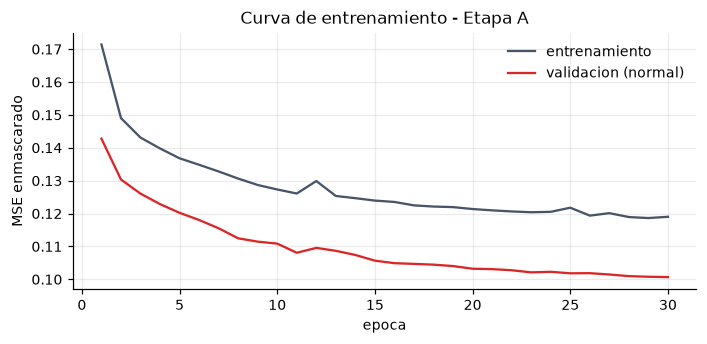

In [33]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(range(1, len(history["train"])+1), history["train"], label="entrenamiento", color="#475569")
ax.plot(range(1, len(history["val"])+1), history["val"], label="validacion (normal)", color="#dc2626")
ax.set_xlabel("epoca"); ax.set_ylabel("MSE enmascarado")
ax.set_title("Curva de entrenamiento - Etapa A")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 14. Score de anomalía por secuencia: elección de la agregación

La Sección 2.2 ya mostró que un remitente positivo tiene en promedio 1.5 transacciones ilícitas sobre ventanas de hasta 64, donde el error de reconstrucción promediado diluiría esa señal entre el resto de la ventana. Este bloque calcula el error por transacción para todas las secuencias y compara, con métricas de ranking independientes del umbral (AUC-ROC, AUC-PR) sobre validación, la media simple contra el máximo y varias medias de los *top-k* errores más altos por ventana.


In [ ]:
all_loader = DataLoader(WindowDataset(np.arange(N_WIN)), batch_size=CFG2["BATCH_SIZE"],shuffle=False, collate_fn=collate_dynamic_padding)

errors_sorted = {}   # indice de ventana -> errores por transaccion, orden descendente
model.eval()
with torch.no_grad():
    for xb, lens, mask, wids in all_loader:
        xb_d, mask_d = xb.to(DEVICE), mask.to(DEVICE)
        recon, _ = model(xb_d, lens)
        err = masked_timestep_error(recon, xb_d, mask_d).cpu().numpy()
        lens_np = lens.numpy()
        for i, w in enumerate(wids.numpy()):
            errors_sorted[int(w)] = np.sort(err[i, :lens_np[i]])[::-1]

score_mean = np.array([errors_sorted[w].mean()    for w in range(N_WIN)])
score_max  = np.array([errors_sorted[w][0]        for w in range(N_WIN)])
score_topk = {k: np.array([errors_sorted[w][:k].mean() for w in range(N_WIN)])
              for k in CFG2["TOPK_GRID"]}

print(f"score de anomalia calculado para las {N_WIN:,} secuencias")


score de anomalia calculado para las 199,364 secuencias


In [35]:
val_idx = np.where(split == 1)[0]
candidates = [("mean", score_mean), ("max", score_max)] + \
             [(f"top-{k}", score_topk[k]) for k in CFG2["TOPK_GRID"]]

rows = []
for name, s in candidates:
    rows.append({
        "agregacion": name,
        "AUC-ROC": roc_auc_score(y[val_idx], s[val_idx]),
        "AUC-PR": average_precision_score(y[val_idx], s[val_idx]),
    })
agg_df = pd.DataFrame(rows).sort_values("AUC-PR", ascending=False)
print("COMPARACION DE AGREGACIONES DEL SCORE (validacion)")
print(agg_df.round(3).to_string(index=False))


COMPARACION DE AGREGACIONES DEL SCORE (validacion)
agregacion  AUC-ROC  AUC-PR
      mean    0.580   0.021
       max    0.570   0.020
     top-1    0.570   0.020
     top-2    0.560   0.019
     top-3    0.548   0.018
    top-16    0.555   0.017
     top-5    0.541   0.017
     top-8    0.544   0.017


In [ ]:
best_name, best_score_arr = max(candidates, key=lambda kv: average_precision_score(y[val_idx], kv[1][val_idx]))
mean_ap  = average_precision_score(y[val_idx], score_mean[val_idx])
best_ap  = average_precision_score(y[val_idx], best_score_arr[val_idx])
best_auc = roc_auc_score(y[val_idx], best_score_arr[val_idx])

print(f"Decision 15 | agregacion elegida para el score de anomalia: {best_name}")
print(f"  AUC-PR  = {best_ap:.3f}  (vs. {mean_ap:.3f} con la media simple)")
print(f"  AUC-ROC = {best_auc:.3f}")

SCORE = best_score_arr


Decision 15 | agregacion elegida para el score de anomalia: mean
  AUC-PR  = 0.021  (vs. 0.021 con la media simple)
  AUC-ROC = 0.580


## 15. Selección del umbral de decisión

Con un desbalance de ~1.5% de positivos, el punto de operación se elige sobre la curva precisión-recall de validación, maximizando F1. Ese umbral no es la única opción posible, ya que la tabla de puntos alternativos deja explícito el costo en tasa de alerta de exigir más recall, para que un equipo de cumplimiento pueda desplazar el punto de operación según cuántas alertas puede revisar al día.


In [37]:
prec, rec, thr = precision_recall_curve(y[val_idx], SCORE[val_idx])
f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec + 1e-12), 0.0)
best_i = int(np.argmax(f1[:-1])) if len(thr) > 0 else 0
THRESHOLD = float(thr[best_i]) if len(thr) > 0 else float(SCORE[val_idx].max())

print(f"umbral elegido (maximo F1 en validacion): {THRESHOLD:.4f}")
print(f"  precision={prec[best_i]:.3f}  recall={rec[best_i]:.3f}  F1={f1[best_i]:.3f}")
alert_rate = float((SCORE[val_idx] >= THRESHOLD).mean())
print(f"  tasa de alerta en validacion: {100*alert_rate:.2f}% de las secuencias")

targets_recall = [0.5, 0.7, 0.8, 0.9, 0.95]
op_rows = []
for tr_ in targets_recall:
    idxs = np.where(rec[:-1] >= tr_)[0]
    if len(idxs) == 0:
        continue
    i = idxs[np.argmax(prec[:-1][idxs])]        # mejor precision entre los que alcanzan ese recall
    op_rows.append({"recall_objetivo": tr_, "umbral": thr[i], "precision": prec[i],
                     "recall_real": rec[i], "tasa_alerta_%": 100*(SCORE[val_idx] >= thr[i]).mean()})
print("\nPUNTOS DE OPERACION ALTERNATIVOS (validacion)")
print(pd.DataFrame(op_rows).round(4).to_string(index=False))


umbral elegido (maximo F1 en validacion): 0.1146
  precision=0.026  recall=0.333  F1=0.048
  tasa de alerta en validacion: 19.21% de las secuencias

PUNTOS DE OPERACION ALTERNATIVOS (validacion)
 recall_objetivo  umbral  precision  recall_real  tasa_alerta_%
            0.50  0.0884     0.0217       0.5166        35.9137
            0.70  0.0361     0.0166       0.7295        66.4705
            0.80  0.0203     0.0158       0.8381        79.9498
            0.90  0.0103     0.0156       0.9512        92.1150
            0.95  0.0103     0.0156       0.9512        92.1150


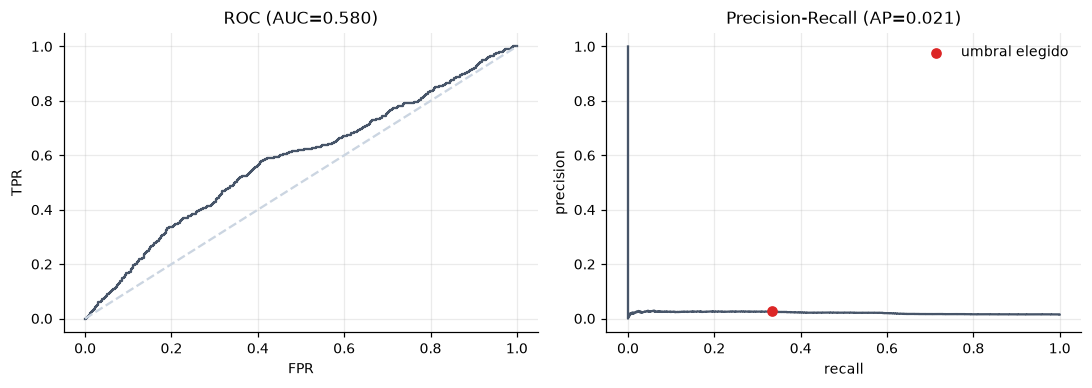

In [38]:
fpr, tpr, _ = roc_curve(y[val_idx], SCORE[val_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

ax[0].plot(fpr, tpr, color="#475569")
ax[0].plot([0, 1], [0, 1], "--", color="#cbd5e1")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title(f"ROC (AUC={best_auc:.3f})")

ax[1].plot(rec, prec, color="#475569")
ax[1].scatter([rec[best_i]], [prec[best_i]], color="#dc2626", zorder=5, label="umbral elegido")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].set_title(f"Precision-Recall (AP={best_ap:.3f})")
ax[1].legend(frameon=False)

plt.tight_layout(); plt.show()


## 16. Evaluación en validación y prueba

El umbral se congela en el valor elegido sobre validación y se aplica sin ajustes al conjunto de prueba. Siguiendo la Decisión 3 del Componente 1, el desempeño en prueba también se desglosa con y sin la cohorte institucional, para no atribuirle al sistema una capacidad de detección que en realidad está limitada a las cuentas hub de alto volumen.


In [39]:
def evaluate(idx, name):
    pred = (SCORE[idx] >= THRESHOLD).astype(int)
    p = precision_score(y[idx], pred, zero_division=0)
    r = recall_score(y[idx], pred, zero_division=0)
    f = f1_score(y[idx], pred, zero_division=0)
    cm = confusion_matrix(y[idx], pred, labels=[0, 1])
    print(f"{name:<16} n={len(idx):>7,}  precision={p:.3f}  recall={r:.3f}  F1={f:.3f}  "
          f"alertas={pred.sum():,} ({100*pred.mean():.2f}%)")
    return dict(split=name, n=len(idx), precision=p, recall=r, f1=f,
                tn=int(cm[0,0]), fp=int(cm[0,1]), fn=int(cm[1,0]), tp=int(cm[1,1]))

test_idx = np.where(split == 2)[0]
print("DESEMPENO CON EL UMBRAL FIJO DE VALIDACION")
res_val  = evaluate(val_idx,  "validacion")
res_test = evaluate(test_idx, "prueba")

print("\nDESGLOSE EN PRUEBA POR COHORTE (Decision 3, Componente 1)")
inst_mask_test = is_institutional[sender_code[test_idx]]
evaluate(test_idx[~inst_mask_test], "no-institucional")
if inst_mask_test.sum() > 0:
    evaluate(test_idx[inst_mask_test], "institucional")
else:
    print("institucional     n=0  (sin cuentas institucionales en el split de prueba)")


DESEMPENO CON EL UMBRAL FIJO DE VALIDACION
validacion       n= 29,905  precision=0.026  recall=0.333  F1=0.048  alertas=5,745 (19.21%)
prueba           n= 29,904  precision=0.025  recall=0.329  F1=0.047  alertas=5,868 (19.62%)

DESGLOSE EN PRUEBA POR COHORTE (Decision 3, Componente 1)
no-institucional n= 29,904  precision=0.025  recall=0.329  F1=0.047  alertas=5,868 (19.62%)
institucional     n=0  (sin cuentas institucionales en el split de prueba)


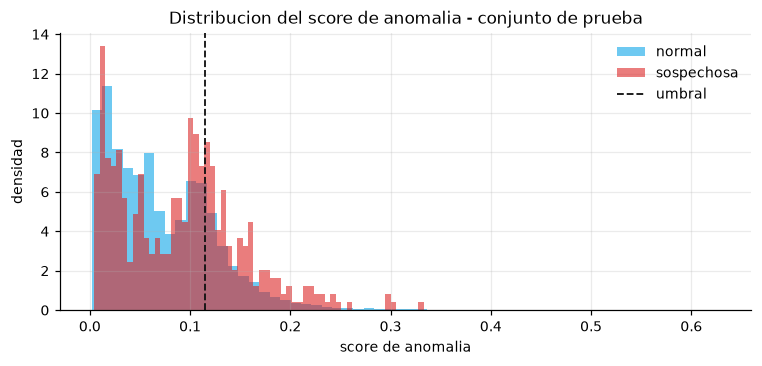

In [40]:
fig, ax = plt.subplots(figsize=(7, 3.4))
s_test = SCORE[test_idx]
ax.hist(s_test[y[test_idx] == 0], bins=60, alpha=0.6, label="normal", color="#0ea5e9", density=True)
ax.hist(s_test[y[test_idx] == 1], bins=60, alpha=0.6, label="sospechosa", color="#dc2626", density=True)
ax.axvline(THRESHOLD, color="#111", ls="--", lw=1.2, label="umbral")
ax.set_xlabel("score de anomalia"); ax.set_ylabel("densidad")
ax.set_title("Distribucion del score de anomalia - conjunto de prueba")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 17. Trazabilidad: qué transacciones activan una alerta

El contexto del proyecto exige que el sistema pueda explicar qué transacciones específicas de un remitente activaron la alerta, no solo emitir un score agregado. Como el score final ya se construye a partir de los errores individuales por transacción (Sección 14), esa trazabilidad viene incluida y basta con ordenar las transacciones de la ventana marcada por su propio error de reconstrucción.


In [41]:
def explain_window(w, k=5):
    """Las k transacciones con mayor error de reconstruccion dentro de una ventana:
    la evidencia que un analista revisaria para justificar la alerta."""
    a, b = int(win_start[w]), int(win_end[w])
    seq = X[a:b]
    with torch.no_grad():
        xb = torch.from_numpy(seq).unsqueeze(0).to(DEVICE)
        lens = torch.tensor([seq.shape[0]])
        mask = torch.ones(1, seq.shape[0], dtype=torch.bool).to(DEVICE)
        recon, _ = model(xb, lens)
        err = masked_timestep_error(recon, xb, mask).cpu().numpy()[0]
    order = np.argsort(err)[::-1][:k]
    return pd.DataFrame({"posicion_en_ventana": order, "error_reconstruccion": err[order]})


flagged_test = test_idx[(SCORE[test_idx] >= THRESHOLD) & (y[test_idx] == 1)]
if len(flagged_test) > 0:
    ejemplo = int(flagged_test[np.argmax(SCORE[flagged_test])])
    print(f"ejemplo: ventana {ejemplo}  (remitente {meta['sender_names'][sender_code[ejemplo]]}, "
          f"score={SCORE[ejemplo]:.3f})")
    print(explain_window(ejemplo).to_string(index=False))
else:
    print("ningun positivo de prueba supero el umbral en esta corrida; revisar tras entrenar")
    print("con los datos completos (esperable solo si el modelo aun no converge).")


ejemplo: ventana 40399  (remitente 80BC2A1D0, score=0.333)
 posicion_en_ventana  error_reconstruccion
                   4              0.745625
                   3              0.377389
                   2              0.266143
                   1              0.176588
                   0              0.098680


## 18. Exportación de artefactos de la Etapa A

Se guarda el score de anomalía de todas las secuencias para que el Componente 2 pueda usarlo como *feature* adicional al combinar ambas etapas, junto con los pesos del modelo y los metadatos de entrenamiento/evaluación necesarios para reproducir esta sección sin reentrenar.


In [42]:
np.savez(
    OUT_DIR / "stage_a_scores.npz",
    score=SCORE, score_mean=score_mean, score_max=score_max,
    **{f"score_top{k}": v for k, v in score_topk.items()},
    y=y, split=split, sender_code=sender_code, threshold=THRESHOLD,
)

stage_a_meta = dict(
    aggregation=best_name,
    threshold=THRESHOLD,
    cfg=CFG2,
    history=history,
    val_metrics=res_val,
    test_metrics=res_test,
    n_epochs_trained=len(history["train"]),
)
with open(OUT_DIR / "stage_a_meta.json", "w") as f:
    json.dump(stage_a_meta, f, indent=2)

torch.save({"state_dict": model.state_dict(), "cfg": CFG2, "n_features": N_FEATS},
           OUT_DIR / "stage_a_model.pt")

for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<24} {p.stat().st_size/1e6:>8,.2f} MB")

alertas_test = res_test["tp"] + res_test["fp"]
print("\nRESUMEN ETAPA A (para el reporte)")
print(f"  agregacion elegida                : {best_name}")
print(f"  umbral                            : {THRESHOLD:.4f}")
print(f"  AUC-ROC / AUC-PR (validacion)      : {best_auc:.3f} / {best_ap:.3f}")
print(f"  precision / recall / F1 (prueba)   : {res_test['precision']:.3f} / {res_test['recall']:.3f} / {res_test['f1']:.3f}")
print(f"  alertas en prueba                  : {alertas_test:,} de {res_test['n']:,} ({100*alertas_test/res_test['n']:.2f}%)")


  meta.json                    2.42 MB
  sequences.npz              452.04 MB
  stage_a_meta.json            0.00 MB
  stage_a_model.pt             0.20 MB
  stage_a_scores.npz           9.77 MB
  test_tx.parquet             10.07 MB

RESUMEN ETAPA A (para el reporte)
  agregacion elegida                : mean
  umbral                            : 0.1146
  AUC-ROC / AUC-PR (validacion)      : 0.580 / 0.021
  precision / recall / F1 (prueba)   : 0.025 / 0.329 / 0.047
  alertas en prueba                  : 5,868 de 29,904 (19.62%)


## Resumen de decisiones: Etapa A

|  #   | Decisión                                                          | Justificación                                                                                                                    |
| :--: | ------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------- |
| **11** | Autoencoder LSTM encoder-decoder, no Transformer                 | Costo lineal en la longitud de secuencia; la atención se reserva para la Etapa B, con un conjunto de entrenamiento seis veces menor |
| **12** | Decodificador "repeat-vector" en vez de autoregresivo            | Evita el *exposure bias*; suficiente porque el objetivo es reconstruir, no generar                                                |
| **13** | Relleno dinámico por lote + máscara en la pérdida                | Evita materializar un tensor fijo (N,64,24) y que el relleno contamine el error de reconstrucción                                 |
| **14** | Validación de la Etapa A aproximada con `y=0` del split de validación | El artefacto no exporta la máscara "remitente limpio" fuera de *train*; limitación documentada explícitamente                |
| **15** | Score de anomalía por *top-k*                 | Un remitente positivo tiene ~1.5 transacciones ilícitas en ventanas de hasta 64; el promedio diluye la señal (Sección 2.2)         |
| **16** | Umbral por F1 máximo sobre la curva precisión-recall de validación | Con ~1.5% de positivos el ROC es poco informativo; se reportan además puntos de operación alternativos para ajuste operativo    |


